# 📊 US Superstore Sales & Profitability Analysis (2019–2022)

## 📌 Project Overview
This project analyzes retail sales data to identify key trends, uncover profit leaks, and provide actionable business recommendations.

## 🎯 Objective
- Analyze sales and profit performance  
- Understand the impact of discounts  
- Identify high-performing products and regions  
- Provide data-driven recommendations

##IMPORT LIBRARIES


In [ ]:
##IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt

##LOAD DATASET

In [ ]:
##LOAD DATASET

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/superstore_dataset.csv')

df['order_date'] = pd.to_datetime(df['order_date'])

df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,2019-01-03,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,2019-01-04,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,2019-01-04,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,2019-01-04,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,2019-01-05,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


# 📂 Data Understanding

The dataset contains transactional sales data including customer details, product categories, sales, profit, and discounts.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 18  profit_m

,zip,discount,profit,quantity,sales,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.371723,0.156203,28.656896,3.789574,229.858001,0.120314
std,32063.705315,0.206452,234.260108,2.225110,623.245101,0.466754
min,1040.000000,0.000000,-6599.978000,1.000000,0.444000,-2.750000
25%,23223.000000,0.000000,1.728750,2.000000,17.280000,0.075000
50%,56430.500000,0.200000,8.666500,3.000000,54.490000,0.270000
75%,90008.000000,0.200000,29.364000,5.000000,209.940000,0.362500
max,99301.000000,0.800000,8399.976000,14.000000,22638.480000,0.500000


## 🧹 Data Cleaning

Steps taken:
- Converted date columns  
- Removed missing values  
- Removed duplicates  
- Ensured correct data types

In [ ]:
import pandas as pd
## Convert dates
df['order_date'] = pd.to_datetime(df['order_date'])


##Remove missing values in critical columns
df = df.dropna(subset=['order_id','sales','profit'])
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Ensure numeric columns are correct
df['sales'] = df['sales'].astype(float)
df['profit'] = df['profit'].astype(float)
df['discount'] = df['discount'].astype(float)


In [ ]:
##Remove missing values in critical columns
df = df.dropna(subset=['order_id','sales','profit'])
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
customer,0
manufactory,0
product_name,0
segment,0
category,0
subcategory,0
region,0


#Comparing before vs after cleaning

In [6]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (9994, 19)


#Removing Duplicate

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

In [ ]:
##print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

After removing duplicates: (9993, 19)


## 🔍 Exploratory Data Analysis (EDA)

We explore trends in sales, profit, and discount impact.

In [7]:
# Sales and profit by region
df.groupby('region')[['sales','profit']].sum()

,sales,profit
region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [3]:
# Correlation between sales, profit, discount
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/superstore_dataset.csv')

df[['sales','profit','discount']].corr()

,sales,profit,discount
sales,1.000000,0.479064,-0.028190
profit,0.479064,1.000000,-0.219487
discount,-0.028190,-0.219487,1.000000


In [4]:
# Top categories by sales
df.groupby('category')['sales'].sum().sort_values(ascending=False)

,sales
category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [5]:
# Top categories by profit
df.groupby('category')['profit'].sum().sort_values(ascending=False)


,profit
category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


#KPIs

In [ ]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $2,296,919.49
Total Profit: $286,409.08
Total Orders: 5009
Profit Margin: 12.47%


#Visualizations
 Sales Trend Over Time

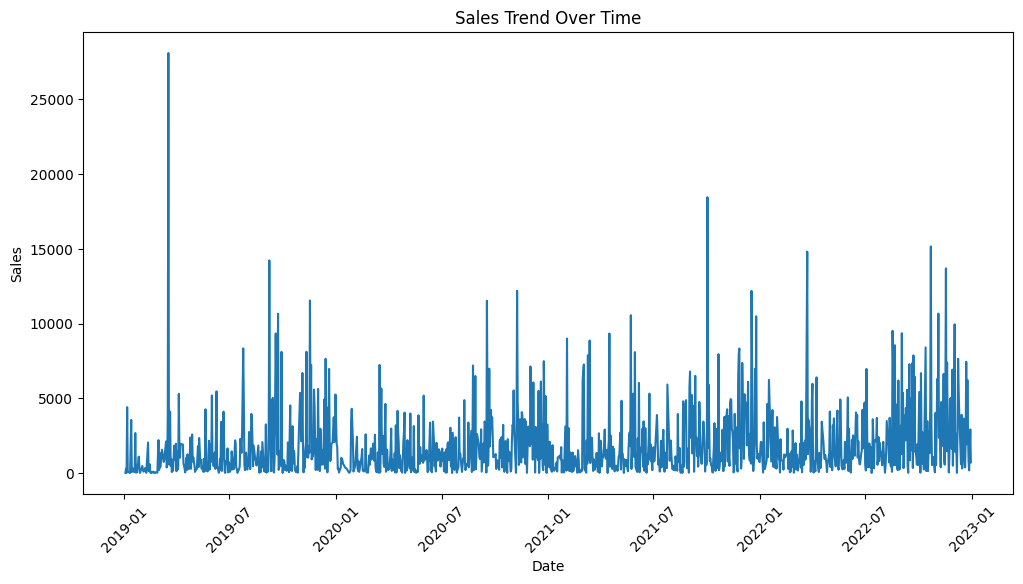

In [ ]:
sales_trend = df.groupby('order_date')['sales'].sum()

plt.figure(figsize=(12,6))
plt.plot(sales_trend)
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

#Sales by Category

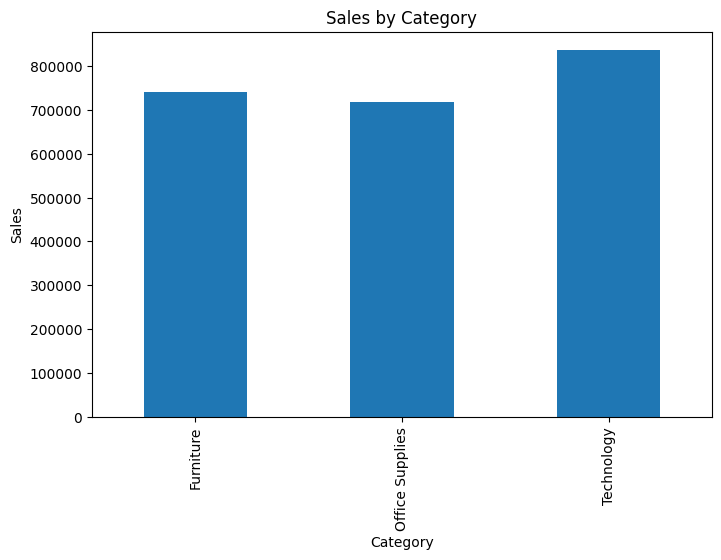

In [ ]:
#Sales by Category

plt.figure(figsize=(8,5))
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

#Profit by Category


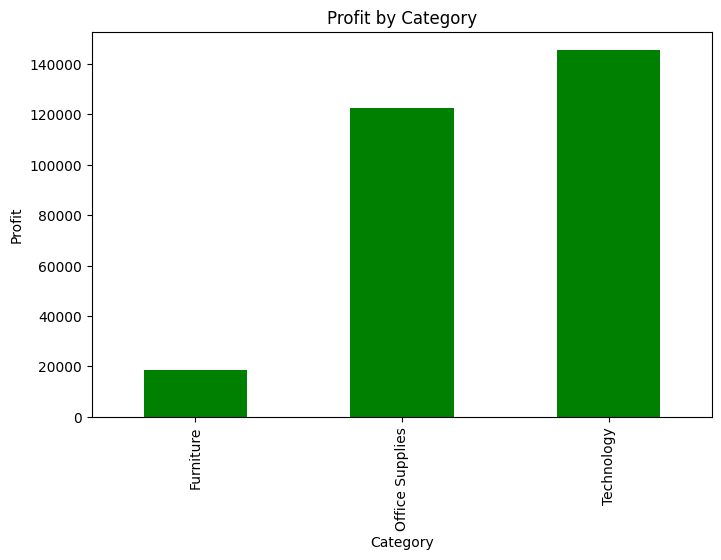

In [ ]:
##Profit by Category

plt.figure(figsize=(8,5))
df.groupby('category')['profit'].sum().plot(kind='bar', color='green')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

#Sales by Region (Pie Chart)

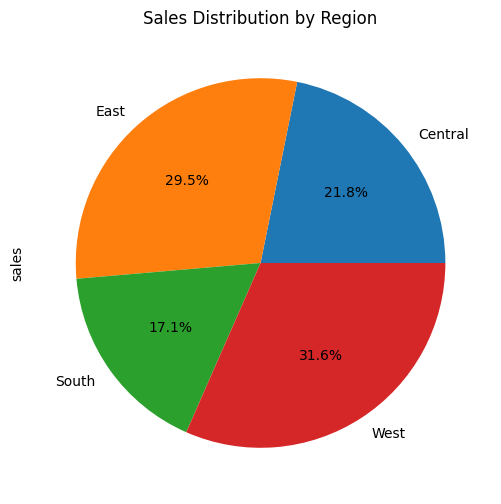

In [ ]:
##Sales by Region (Pie Chart)

plt.figure(figsize=(6,6))
df.groupby('region')['sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Region')
plt.show()

#Top 10 States by Sales

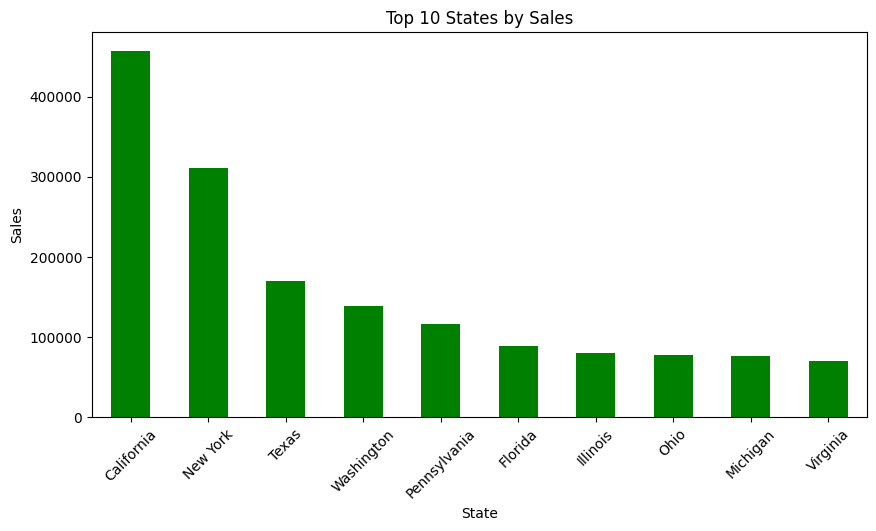

In [ ]:
##Top 10 States by Sales

top_states = df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='green')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

#Discount Impact on Average Profit


/tmp/ipykernel_374/838879381.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_impact = df.groupby('discount_range')['profit'].mean()


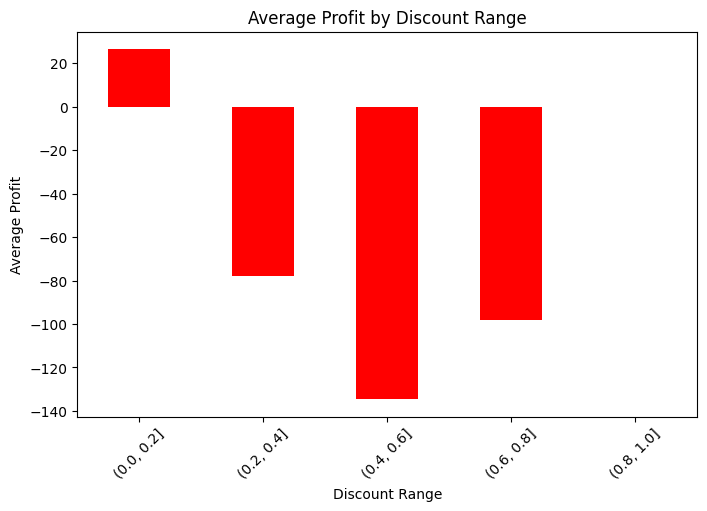

In [ ]:
##Discount Impact on Average Profit

df['discount_range'] = pd.cut(df['discount'], bins=[0,0.2,0.4,0.6,0.8,1.0])

discount_impact = df.groupby('discount_range')['profit'].mean()

plt.figure(figsize=(8,5))
discount_impact.plot(kind='bar', color='red')
plt.title('Average Profit by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()

## 💡 Key Insights

- High discounts (>70%) result in heavy losses
- Technology category drives most revenue, accessories have best profit margins
- Binders and Machines are the worst-performing sub-categories
- Sales concentrated in key urban regions (NY, LA, Houston)

## 🚀 Recommendations

- Reduce excessive discounting (>70%)
- Focus on high-margin products (Technology, Accessories)
- Optimize product mix by region
- Improve pricing strategy for low-profit sub-categories
